In [1]:
import time
from pathlib import Path

import torch
import pandas as pd
import matplotlib.pyplot as plt

from src.colpali.ingestion import ColPaliEncoder
from src.colpali.retrieval import ColPaliQdrantRetriever

In [2]:
MODEL_NAME = "vidore/colpali-v1.3"
DEVICE = "mps"
QDRANT_PATH = ( "../../data/processed/colpali/qdrant")
COLLECTION_NAME = "colpali_pages"
TOP_K = 5

QUERIES = [
    "Explain LoRA: Low-Rank Adaptation of Large Language Models in simple words.",
    "What is the main method proposed in this paper?",
    "What is the objective function used by the proposed method?",
    "What are the experimental results of the proposed method?",
    "What does the main figure in the paper demonstrate?",
]

In [3]:
print("MPS available:", torch.backends.mps.is_available())
print("MPS built:", torch.backends.mps.is_built())

if not torch.backends.mps.is_available():
    raise RuntimeError("MPS is not available.")

print("Loading ColPali...")
encoder = ColPaliEncoder(model_name=MODEL_NAME,device=DEVICE)
print("ColPali loaded...")

model_device = next(encoder.model.parameters()).device
print("Encoder device:", encoder.device)
print("Actual model parameter device:", model_device)

MPS available: True
MPS built: True
Loading ColPali...


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/605 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

ColPali loaded...
Encoder device: mps
Actual model parameter device: mps:0


In [4]:
retriever = ColPaliQdrantRetriever(encoder=encoder,collection_name=COLLECTION_NAME,
                                   qdrant_path=QDRANT_PATH)
print("Retriever initialized.")

Retriever initialized.


In [ ]:
# warmup_query = ("Explain LoRA: Low-Rank Adaptation of Large Language Models in simple words.")
# print("Running warm-up query...")

# _ = retriever.retrieve(query=warmup_query,top_k=TOP_K,)
# print("Warm-up complete.")

Running warm-up query...
Warm-up complete.


## Retrieve with Timing

In [8]:
query = ("Explain GANs in simple words.")
results, timing = retriever.retrieve_with_timing(query=query,top_k=TOP_K,)

print(f"Query encoding : {timing['encoding_ms']:.2f} ms")
print(f"Qdrant search  : {timing['qdrant_ms']:.2f} ms")
print(f"Total retrieval: {timing['total_ms']:.2f} ms")

Query encoding : 891.17 ms
Qdrant search  : 1346.80 ms
Total retrieval: 2237.99 ms


In [9]:
for rank, result in enumerate(results,start=1):
    payload = result["payload"]
    print(
        f"{rank}. "
        f"{payload.get('paper_id')} "
        f"page {payload.get('page_number')} "
        f"score={result['score']:.4f}"
    )

1. 1511.06434 page 1 score=12.9289
2. 2105.05233 page 2 score=12.7270
3. 2105.05233 page 1 score=12.1898
4. 2105.05233 page 6 score=11.8009
5. 2102.09672 page 7 score=11.7350


## Benchmarking Multiple Queries

In [10]:
records = []

for query in QUERIES:
    results, timing = (retriever.retrieve_with_timing(query=query,top_k=TOP_K))
    records.append(
        {
            "query": query,
            "encoding_ms": timing["encoding_ms"],
            "qdrant_ms": timing["qdrant_ms"],
            "total_ms": timing["total_ms"],
        }
    )

latency_df = pd.DataFrame(records)
latency_df

,query,encoding_ms,qdrant_ms,total_ms
0,Explain LoRA: Low-Rank Adaptation of Large Lan...,15348.151333,7185.180084,22533.349625
1,What is the main method proposed in this paper?,861.266667,947.217834,1808.486500
2,What is the objective function used by the pro...,297.239917,223.444000,520.697125
3,What are the experimental results of the propo...,102.674500,149.628083,252.304667
4,What does the main figure in the paper demonst...,83.439125,230.949584,314.391458


In [12]:
latency_df[["encoding_ms","qdrant_ms","total_ms"]].describe()

,encoding_ms,qdrant_ms,total_ms
count,5.000000,5.000000,5.000000
mean,3338.554308,1747.283917,5085.845875
std,6720.931129,3057.150737,9774.033872
min,83.439125,149.628083,252.304667
25%,102.674500,223.444000,314.391458
50%,297.239917,230.949584,520.697125
75%,861.266667,947.217834,1808.486500
max,15348.151333,7185.180084,22533.349625


## P-95 Calculation

In [13]:
latency_summary = {
    "encoding_mean_ms": latency_df["encoding_ms"].mean(),
    "encoding_median_ms": latency_df["encoding_ms"].median(),
    "encoding_p95_ms": latency_df["encoding_ms"].quantile(0.95),

    "qdrant_mean_ms": latency_df["qdrant_ms"].mean(),
    "qdrant_median_ms": latency_df["qdrant_ms"].median(),
    "qdrant_p95_ms": latency_df["qdrant_ms"].quantile(0.95),

    "total_mean_ms": latency_df["total_ms"].mean(),
    "total_median_ms": latency_df["total_ms"].median(),
    "total_p95_ms": latency_df["total_ms"].quantile(0.95),
}

pd.Series(latency_summary)

encoding_mean_ms       3338.554308
encoding_median_ms      297.239917
encoding_p95_ms       12450.774400
qdrant_mean_ms         1747.283917
qdrant_median_ms        230.949584
qdrant_p95_ms          5937.587634
total_mean_ms          5085.845875
total_median_ms         520.697125
total_p95_ms          18388.377000
dtype: float64

In [15]:
if torch.backends.mps.is_available():

    print(
        "Current allocated MPS memory:",
        torch.mps.current_allocated_memory()
        / (1024 ** 2),
        "MB",
    )

    print(
        "Driver allocated MPS memory:",
        torch.mps.driver_allocated_memory()
        / (1024 ** 2),
        "MB",
    )

Current allocated MPS memory: 0.009033203125 MB
Driver allocated MPS memory: 5670.78125 MB


## Controlled Encoding experiments

In [5]:
import time
import pandas as pd
import torch

In [6]:
warmup_query = "What is LoRA?"
print("Running warm-up...")

_, warmup_timing = retriever.retrieve_with_timing(query=warmup_query,top_k=TOP_K)

print(
    f"Warm-up total latency: "
    f"{warmup_timing['total_ms']:.2f} ms"
)

Running warm-up...
Warm-up total latency: 26366.11 ms


In [7]:
IDENTICAL_QUERY = ("Explain LoRA: Low-Rank Adaptation of Large Language Models in simple words.")

N_RUNS = 5

identical_results = []

for run in range(1, N_RUNS + 1):

    _, timing = retriever.retrieve_with_timing(
        query=IDENTICAL_QUERY,
        top_k=TOP_K,
    )

    identical_results.append(
        {
            "experiment": "identical_query",
            "run": run,
            "query": IDENTICAL_QUERY,
            "encoding_ms": timing["encoding_ms"],
            "qdrant_ms": timing["qdrant_ms"],
            "total_ms": timing["total_ms"],
        }
    )

    print(
        f"Run {run}: "
        f"encoding={timing['encoding_ms']:.2f} ms | "
        f"qdrant={timing['qdrant_ms']:.2f} ms | "
        f"total={timing['total_ms']:.2f} ms"
    )

Run 1: encoding=3876.33 ms | qdrant=1396.04 ms | total=5272.44 ms
Run 2: encoding=991.54 ms | qdrant=1216.55 ms | total=2208.10 ms
Run 3: encoding=800.10 ms | qdrant=1037.81 ms | total=1837.91 ms
Run 4: encoding=1380.60 ms | qdrant=1153.93 ms | total=2534.55 ms
Run 5: encoding=1010.33 ms | qdrant=374.33 ms | total=1384.66 ms


In [ ]:
identical_df = pd.DataFrame(identical_results)
identical_df[
    [
        "encoding_ms",
        "qdrant_ms",
        "total_ms",
    ]
].describe()

,encoding_ms,qdrant_ms,total_ms
count,5.000000,5.000000,5.000000
mean,1611.779466,1035.733308,2647.533025
std,1283.250200,391.773414,1528.588844
min,800.095208,374.330667,1384.660917
25%,991.538166,1037.808833,1837.912875
50%,1010.328041,1153.933375,2208.103542
75%,1380.602000,1216.554500,2534.547042
max,3876.333917,1396.039166,5272.440750


In [10]:
identical_summary = {
    "encoding_mean_ms":identical_df["encoding_ms"].mean(),
    "encoding_median_ms":identical_df["encoding_ms"].median(),
    "encoding_std_ms":identical_df["encoding_ms"].std(),
    "qdrant_mean_ms":identical_df["qdrant_ms"].mean(),
    "qdrant_median_ms":identical_df["qdrant_ms"].median(),
    "qdrant_std_ms":identical_df["qdrant_ms"].std(),
    "total_mean_ms":identical_df["total_ms"].mean(),
    "total_median_ms":identical_df["total_ms"].median(),
    "total_std_ms":identical_df["total_ms"].std()}
pd.Series(identical_summary)

encoding_mean_ms      1611.779466
encoding_median_ms    1010.328041
encoding_std_ms       1283.250200
qdrant_mean_ms        1035.733308
qdrant_median_ms      1153.933375
qdrant_std_ms          391.773414
total_mean_ms         2647.533025
total_median_ms       2208.103542
total_std_ms          1528.588844
dtype: float64

## Query Length Experiments

### Short Query

In [11]:
SHORT_QUERY = (
    "What is LoRA?"
)

short_results = []

for run in range(1, N_RUNS + 1):

    _, timing = retriever.retrieve_with_timing(
        query=SHORT_QUERY,
        top_k=TOP_K,
    )

    short_results.append(
        {
            "experiment": "short_query",
            "run": run,
            "query": SHORT_QUERY,
            "encoding_ms": timing["encoding_ms"],
            "qdrant_ms": timing["qdrant_ms"],
            "total_ms": timing["total_ms"],
        }
    )

    print(
        f"Run {run}: "
        f"encoding={timing['encoding_ms']:.2f} ms | "
        f"qdrant={timing['qdrant_ms']:.2f} ms | "
        f"total={timing['total_ms']:.2f} ms"
    )

Run 1: encoding=1245.10 ms | qdrant=2945.49 ms | total=4190.62 ms
Run 2: encoding=994.13 ms | qdrant=1041.01 ms | total=2035.14 ms
Run 3: encoding=1191.85 ms | qdrant=456.99 ms | total=1648.86 ms
Run 4: encoding=276.03 ms | qdrant=689.17 ms | total=965.20 ms
Run 5: encoding=89.67 ms | qdrant=955.33 ms | total=1045.09 ms


### Medium Query

In [12]:
MEDIUM_QUERY = (
    "Explain how LoRA reduces the number of "
    "trainable parameters during fine-tuning."
)

medium_results = []

for run in range(1, N_RUNS + 1):

    _, timing = retriever.retrieve_with_timing(
        query=MEDIUM_QUERY,
        top_k=TOP_K,
    )

    medium_results.append(
        {
            "experiment": "medium_query",
            "run": run,
            "query": MEDIUM_QUERY,
            "encoding_ms": timing["encoding_ms"],
            "qdrant_ms": timing["qdrant_ms"],
            "total_ms": timing["total_ms"],
        }
    )

    print(
        f"Run {run}: "
        f"encoding={timing['encoding_ms']:.2f} ms | "
        f"qdrant={timing['qdrant_ms']:.2f} ms | "
        f"total={timing['total_ms']:.2f} ms"
    )

Run 1: encoding=843.21 ms | qdrant=1231.18 ms | total=2074.40 ms
Run 2: encoding=1231.92 ms | qdrant=194.42 ms | total=1426.35 ms
Run 3: encoding=102.23 ms | qdrant=231.47 ms | total=333.70 ms
Run 4: encoding=73.51 ms | qdrant=192.04 ms | total=265.56 ms
Run 5: encoding=73.35 ms | qdrant=202.66 ms | total=276.01 ms


In [13]:
LONG_QUERY = (
    "Explain how Low-Rank Adaptation of Large Language "
    "Models works, including why the original model "
    "parameters are frozen, how the low-rank matrices "
    "are introduced, how the parameter update is "
    "computed, and why this reduces the computational "
    "and memory requirements of fine-tuning."
)

long_results = []

for run in range(1, N_RUNS + 1):

    _, timing = retriever.retrieve_with_timing(
        query=LONG_QUERY,
        top_k=TOP_K,
    )

    long_results.append(
        {
            "experiment": "long_query",
            "run": run,
            "query": LONG_QUERY,
            "encoding_ms": timing["encoding_ms"],
            "qdrant_ms": timing["qdrant_ms"],
            "total_ms": timing["total_ms"],
        }
    )

    print(
        f"Run {run}: "
        f"encoding={timing['encoding_ms']:.2f} ms | "
        f"qdrant={timing['qdrant_ms']:.2f} ms | "
        f"total={timing['total_ms']:.2f} ms"
    )

Run 1: encoding=998.88 ms | qdrant=1212.88 ms | total=2211.80 ms
Run 2: encoding=1347.68 ms | qdrant=265.53 ms | total=1613.22 ms
Run 3: encoding=145.87 ms | qdrant=218.26 ms | total=364.13 ms
Run 4: encoding=111.94 ms | qdrant=227.78 ms | total=339.72 ms
Run 5: encoding=111.11 ms | qdrant=216.29 ms | total=327.40 ms


In [14]:
all_results = (
    identical_results
    + short_results
    + medium_results
    + long_results
)

latency_experiment_df = pd.DataFrame(
    all_results
)

latency_experiment_df

,experiment,run,query,encoding_ms,qdrant_ms,total_ms
0,identical_query,1,Explain LoRA: Low-Rank Adaptation of Large Lan...,3876.333917,1396.039166,5272.440750
1,identical_query,2,Explain LoRA: Low-Rank Adaptation of Large Lan...,991.538166,1216.554500,2208.103542
2,identical_query,3,Explain LoRA: Low-Rank Adaptation of Large Lan...,800.095208,1037.808833,1837.912875
3,identical_query,4,Explain LoRA: Low-Rank Adaptation of Large Lan...,1380.602000,1153.933375,2534.547042
4,identical_query,5,Explain LoRA: Low-Rank Adaptation of Large Lan...,1010.328041,374.330667,1384.660917
5,short_query,1,What is LoRA?,1245.101666,2945.488375,4190.620792
6,short_query,2,What is LoRA?,994.130167,1041.009917,2035.141750
7,short_query,3,What is LoRA?,1191.845250,456.991417,1648.863625
8,short_query,4,What is LoRA?,276.026792,689.167208,965.204875
9,short_query,5,What is LoRA?,89.666041,955.333833,1045.086584


In [15]:
comparison = (
    latency_experiment_df
    .groupby("experiment")
    [
        [
            "encoding_ms",
            "qdrant_ms",
            "total_ms",
        ]
    ]
    .agg(
        [
            "mean",
            "median",
            "std",
        ]
    )
)

comparison

encoding_ms                              qdrant_ms  \
                        mean       median          std         mean   
experiment                                                            
identical_query  1611.779466  1010.328041  1283.250200  1035.733308   
long_query        543.093817   145.866125   588.512430   428.148658   
medium_query      464.844125   102.225583   540.711637   410.355858   
short_query       759.353983   994.130167   538.564406  1217.598150   

                                             total_ms               \
                      median         std         mean       median   
experiment                                                           
identical_query  1153.933375  391.773414  2647.533025  2208.103542   
long_query        227.777542  439.127085   971.253383   364.130916   
medium_query      202.662875  459.121457   875.203942   333.700250   
short_query       955.333833  992.891292  1976.983525  1648.863625   

                              
                         std  
experiment                    
identical_query  1528.588844  
long_query        885.019817  
medium_query      831.528920  
short_query      1313.712577

In [16]:
p95_comparison = (
    latency_experiment_df
    .groupby("experiment")
    [
        [
            "encoding_ms",
            "qdrant_ms",
            "total_ms",
        ]
    ]
    .quantile(0.95)
)

p95_comparison

,encoding_ms,qdrant_ms,total_ms
experiment,,,
identical_query,3377.187534,1360.142233,4724.862008
long_query,1277.916475,1023.409691,2092.079899
medium_query,1154.180975,1031.236008,1944.790675
short_query,1234.450383,2564.592683,3759.524984


<Figure size 1000x500 with 0 Axes>

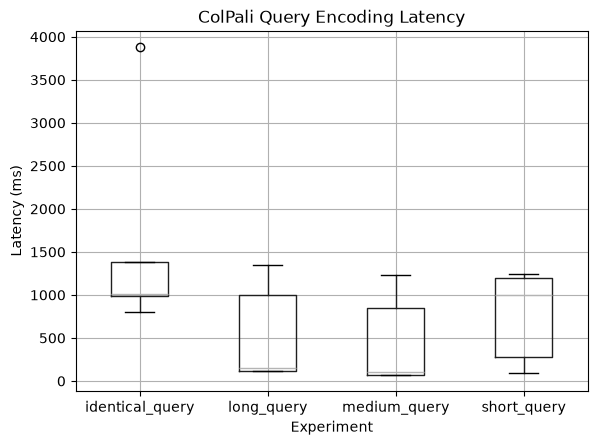

In [17]:
plt.figure(figsize=(10, 5))

latency_experiment_df.boxplot(
    column="encoding_ms",
    by="experiment",
)

plt.title(
    "ColPali Query Encoding Latency"
)

plt.suptitle("")

plt.ylabel("Latency (ms)")
plt.xlabel("Experiment")

plt.show()

In [18]:
latency_experiment_df["query_chars"] = (
    latency_experiment_df["query"]
    .str.len()
)

latency_experiment_df[
    [
        "experiment",
        "run",
        "query_chars",
        "encoding_ms",
        "qdrant_ms",
        "total_ms",
    ]
]

,experiment,run,query_chars,encoding_ms,qdrant_ms,total_ms
0,identical_query,1,75,3876.333917,1396.039166,5272.440750
1,identical_query,2,75,991.538166,1216.554500,2208.103542
2,identical_query,3,75,800.095208,1037.808833,1837.912875
3,identical_query,4,75,1380.602000,1153.933375,2534.547042
4,identical_query,5,75,1010.328041,374.330667,1384.660917
5,short_query,1,13,1245.101666,2945.488375,4190.620792
6,short_query,2,13,994.130167,1041.009917,2035.141750
7,short_query,3,13,1191.845250,456.991417,1648.863625
8,short_query,4,13,276.026792,689.167208,965.204875
9,short_query,5,13,89.666041,955.333833,1045.086584


In [19]:
length_summary = (
    latency_experiment_df
    .groupby("experiment")
    .agg(
        query_chars=("query_chars", "first"),
        encoding_mean_ms=("encoding_ms", "mean"),
        encoding_median_ms=("encoding_ms", "median"),
        total_mean_ms=("total_ms", "mean"),
        total_median_ms=("total_ms", "median"),
    )
    .sort_values("query_chars")
)

length_summary

,query_chars,encoding_mean_ms,encoding_median_ms,total_mean_ms,total_median_ms
experiment,,,,,
short_query,13,759.353983,994.130167,1976.983525,1648.863625
identical_query,75,1611.779466,1010.328041,2647.533025,2208.103542
medium_query,79,464.844125,102.225583,875.203942,333.700250
long_query,278,543.093817,145.866125,971.253383,364.130916
